# Introduction

In data science, we often work with a **sample dataset** to make conclusions about a larger population. This process is known as **Inferential Statistics**.

This notebook focuses on applying inferential statistical techniques on a real-world-like dataset of student performance.

---

# Objectives

The main goals of this notebook are:

- Understand the dataset through Exploratory Data Analysis (EDA)
- Apply key inferential statistics concepts:
  - Confidence Intervals
  - One Sample Z-Test
  - One Sample T-Test
  - Chi-Square Test
  - ANOVA (Analysis of Variance)
  - P-Value Interpretation
- Build intuition behind statistical decision-making

# Data Overview

In [2]:
import pandas as pd
import numpy as np
df=pd.read_csv('/kaggle/input/datasets/sudhanshu3112/student-exam-scores-and-demographics/students_performance_datasets.csv')

In [3]:
df.head(3)

,student_id,gender,age,race/ethnicity,parental level of education,lunch,test preparation course,study_hours_per_day,attendance_percentage,math score,reading score,writing score
0,1,female,18,group B,bachelor's degree,free/reduced,completed,2.49,69.03,67,67,66
1,2,male,17,group C,some high school,standard,completed,7.77,73.54,71,98,69
2,3,male,20,group D,bachelor's degree,free/reduced,none,2.64,66.82,76,59,64


In [4]:
df.shape

(300, 12)

In [5]:
df.describe()

,student_id,age,study_hours_per_day,attendance_percentage,math score,reading score,writing score
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,17.570000,5.571033,79.615600,74.623333,77.300000,76.853333
std,86.746758,1.641365,2.581230,11.342494,12.361126,11.838235,12.225521
min,1.000000,15.000000,1.040000,60.010000,40.000000,44.000000,44.000000
25%,75.750000,16.000000,3.235000,69.992500,66.000000,69.000000,68.750000
50%,150.500000,18.000000,5.660000,79.550000,74.000000,77.000000,77.000000
75%,225.250000,19.000000,7.625000,89.115000,83.000000,86.000000,86.000000
max,300.000000,20.000000,9.980000,99.910000,100.000000,100.000000,100.000000


# EDA

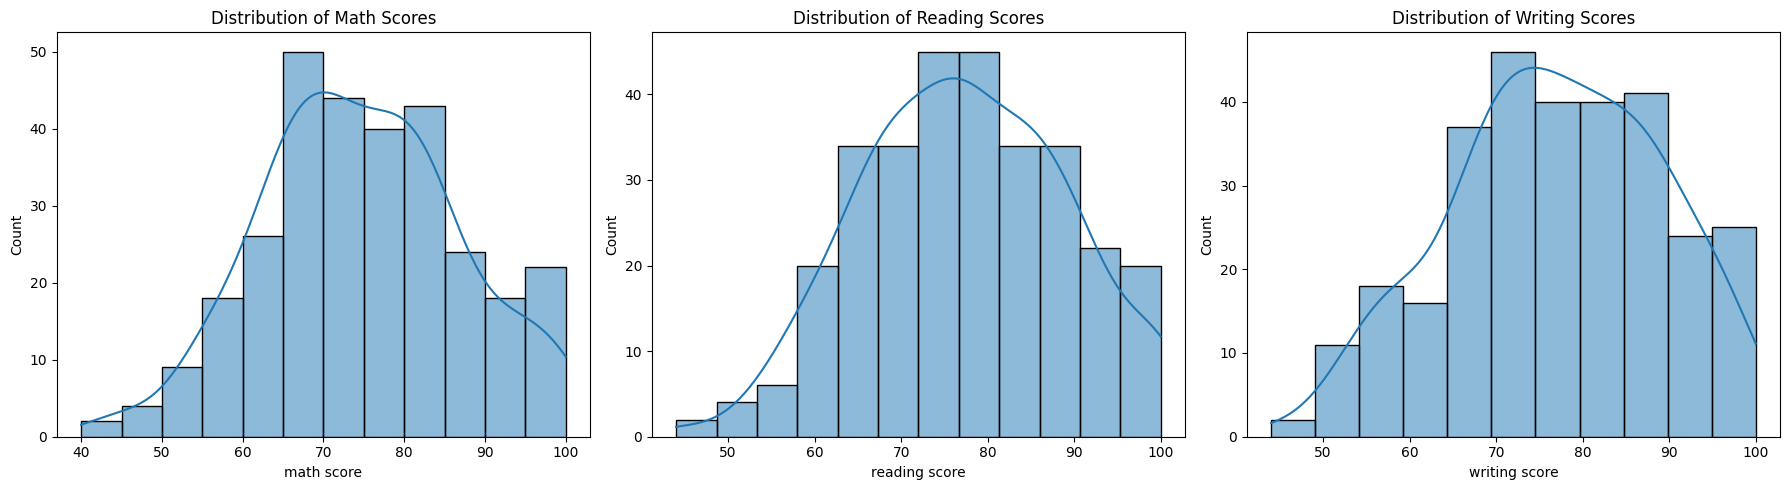

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['math score'], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Math Scores")

sns.histplot(df['reading score'], kde=True, ax=axes[1])
axes[1].set_title("Distribution of Reading Scores")

sns.histplot(df['writing score'], kde=True, ax=axes[2])
axes[2].set_title("Distribution of Writing Scores")

plt.tight_layout()
plt.show()


#  Confidence Interval

## What is a Confidence Interval?

A Confidence Interval (CI) is a range of values used to estimate the true population parameter (such as mean).

Instead of giving a single value, we provide a range within which the true value is likely to lie.

---

##  Why Confidence Interval?

- Helps in estimating population mean from sample data
- Provides a measure of uncertainty
- More informative than a single mean value

---

##  Formula (for large sample / known variance)

Confidence Interval = 

mean ± Z * (σ / √n)


In [7]:
import scipy.stats as stats

# Step 1: sample data
data = df['math score']

# Step 2: calculate values
mean = np.mean(data)
std = np.std(data, ddof=1)
n = len(data)

# Step 3: Z-score for 95% confidence
z = 1.96

# Step 4: margin of error
margin_error = z * (std / np.sqrt(n))

# Step 5: confidence interval
lower = mean - margin_error
upper = mean + margin_error

print("Mean:", mean)
print("Confidence Interval:", (lower, upper))

Mean: 74.62333333333333
Confidence Interval: (np.float64(73.22454019569552), np.float64(76.02212647097114))


**Result**:We are **95% confident** that the true population mean of math scores lies between: **73.22 and 76.02**

 

# HYPOTHESIS TESTING (T-TEST)

##  What is a T-Test?

A One Sample T-Test is used to determine whether the mean of a sample is significantly different from a known or hypothesized population mean.

---

##  Problem Statement

We want to test:

 Is the average math score of students equal to 75?

---

##  Hypotheses

- Null Hypothesis (H₀):  
  The mean math score = 75  

- Alternative Hypothesis (H₁):  
  The mean math score ≠ 75  

(This is a two-tailed test)

We will use:

 α = 0.05 (95% confidence level)

In [8]:
# Step 1: sample data
data = df['math score']

# Step 2: hypothesized mean
mu = 75

# Step 3: perform t-test
t_stat, p_value = stats.ttest_1samp(data, mu)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -0.5277883103668911
P-Value: 0.5980377158209242



**Since p-value is greater than 0.05, we fail to reject the null hypothesis, meaning there is no statistically significant difference between the sample mean and the hypothesized mean of 75.**

#  Z-Test

## What is a Z-Test?

A Z-Test is used to determine whether the sample mean is significantly different from the population mean when:

- Sample size is large (n > 30)  
- Population standard deviation is known (or approximated using sample std)

 α = 0.05

## Z-Test Formula
$$Z = \frac{\bar{x} - \mu}{\frac{\sigma}{\sqrt{n}}}$$

**Where:**
* $\bar{x}$ = Sample Mean
* $\mu$ = Population Mean
* $\sigma$ = Population Standard Deviation
* $n$ = Sample Size

In [9]:
# sample data
data = df['math score']

# values
mean = np.mean(data)
std = np.std(data, ddof=1)
n = len(data)
mu = 75

# Z-statistic
z_stat = (mean - mu) / (std / np.sqrt(n))

# p-value (two-tailed)
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("Z-Statistic:", z_stat)
print("P-Value:", p_value)

Z-Statistic: -0.5277883103668911
P-Value: 0.597646271447978


## Conclusion

- **P-Value > α → Fail to Reject H₀**
- There is **no significant difference** between the sample mean and 75  
- The average math score is **approximately equal to 75**

# Chi-Square Test
##  What is Chi-Square Test?

The Chi-Square Test is used to determine whether two categorical variables are independent or related.

---
## Formula
The Chi-Square statistic is calculated by comparing **Observed (O)** values with **Expected (E)** values:

$$\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$$

**Where:**
*   $\chi^2$ = Chi-Square statistic
*   $O_i$ = Observed frequency (Actual data)
*   $E_i$ = Expected frequency (What we expect if there is no relationship)
*   $\sum$ = Summation over all categories

In [10]:
# Step 1: create contingency table
table = pd.crosstab(df['gender'], df['test preparation course'])

print("Contingency Table:\n", table)

# Step 2: chi-square test
chi2, p, dof, expected = stats.chi2_contingency(table)

print("\nChi-Square Statistic:", chi2)
print("P-Value:", p)
print("Degrees of Freedom:", dof)

Contingency Table:
 test preparation course  completed  none
gender                                  
female                          67    77
male                            72    84

Chi-Square Statistic: 0.0
P-Value: 1.0
Degrees of Freedom: 1


## Conclusion

- There is **no relationship** between gender and test preparation course  
- Both variables are **independent**

#  ANOVA (Analysis of Variance)

##  What is ANOVA?

ANOVA is used to compare the means of **more than two groups** to determine if at least one group mean is different.


## One way Anova

**Tests if one independent categorical variable (with 3+ groups) affects a numerical outcome.**

In [11]:
import scipy.stats as stats

# Step 1: group data
groups = df.groupby('parental level of education')['math score'].apply(list)

# Convert to list of arrays
group_values = [group for group in groups]

# Step 2: ANOVA test
f_stat, p_value = stats.f_oneway(*group_values)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

F-Statistic: 0.4561688028377516
P-Value: 0.8086719892191331



## Two-Way ANOVA

Two-Way ANOVA is used to study the effect of **two independent categorical variables** on one numerical variable.

It also helps us understand:
- Individual effects of each variable
- Interaction effect between variables

---

**Problem Statement:Do **gender** and **test preparation course** affect **math scores**?**


In [12]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Q("math score") ~ C(gender) + C(Q("test preparation course")) + C(gender):C(Q("test preparation course"))', data=df).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
C(gender),3.327370,1.0,0.021915,0.882415
"C(Q(""test preparation course""))",197.232829,1.0,1.299016,0.255315
"C(gender):C(Q(""test preparation course""))",543.252330,1.0,3.577971,0.059527
Residual,44942.429371,296.0,NaN,NaN


## Result

*   **Gender:** P-value (0.88) > 0.05 → **Not Significant**.
*   **Test Prep Course:** P-value (0.25) > 0.05 → **Not Significant**.
*   **Interaction (Gender * Course):** P-value (0.059) > 0.05 → **Not Significant** (but close).

**Conclusion:** Neither gender nor the preparation course significantly impacts the scores in this dataset. We **fail to reject** the Null Hypothesis for all factors.


# P-Value

##  What is a P-Value?

The P-Value measures the probability of obtaining results at least as extreme as the observed results, assuming the null hypothesis is true.

---

##  Key Idea

- **Low P-Value (≤ 0.05):**
  - Strong evidence against H₀  
  - Reject the null hypothesis  

- **High P-Value (> 0.05):**
  - Weak evidence against H₀  
  - Fail to reject the null hypothesis  

---

##  Common Misconceptions

- ❌ P-Value is NOT the probability that H₀ is true  
- ❌ P-Value does NOT measure effect size  
- ❌ P-Value alone is not enough (context matters)

---

##  In This Notebook

Across all tests (T-Test, Z-Test, Chi-Square, ANOVA),  
we consistently observed:

 **P-Value > 0.05**

---

##  Interpretation

- There is **no statistically significant evidence**  
- Most variables in this dataset appear to be **independent or weakly related**

#  Final Conclusion

 **Summary of Findings:-**

- **Confidence Interval:**
  - Mean math score lies between **73.22 and 76.02**

- **T-Test & Z-Test:**
  - No significant difference from hypothesized mean (75)

- **Chi-Square Test:**
  - Gender and test preparation are **independent**

- **One-Way ANOVA:**
  - Parental education does **not significantly affect** math scores

- **Two-Way ANOVA:**
  - Gender and test preparation do not significantly affect math scores  
  - Interaction effect is weak and not significant

---

